In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report,mean_squared_error

In [47]:
df=pd.read_csv("/content/Fake News Detection Dataset.csv")
df.head()

,ID,Word_Count,Number_of_Sentence,Unique_Words,Average_Word_Length,Label
0,1606,10,4,24,6.176750,1
1,3718,10,8,25,5.826770,1
2,2634,10,7,18,4.619040,1
3,5560,10,6,18,4.961424,1
4,7494,10,4,21,4.114324,1


In [48]:
df.describe()

,ID,Word_Count,Number_of_Sentence,Unique_Words,Average_Word_Length,Label
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,5469.140000,53.934000,8.934667,24.943333,4.968105,0.329556
std,2599.193059,24.872743,3.407847,11.540708,1.152394,0.470104
min,1002.000000,10.000000,4.000000,5.000000,3.000385,0.000000
25%,3228.750000,35.000000,6.000000,17.000000,3.980553,0.000000
50%,5449.500000,52.000000,9.000000,22.000000,4.906200,0.000000
75%,7706.750000,75.000000,12.000000,33.000000,5.996111,1.000000
max,9999.000000,100.000000,15.000000,50.000000,6.999799,1.000000


In [49]:
df['Unique_Words'].corr(df['Label'])

np.float64(-0.29964729028013315)

<Axes: xlabel='Label', ylabel='Unique_Words'>

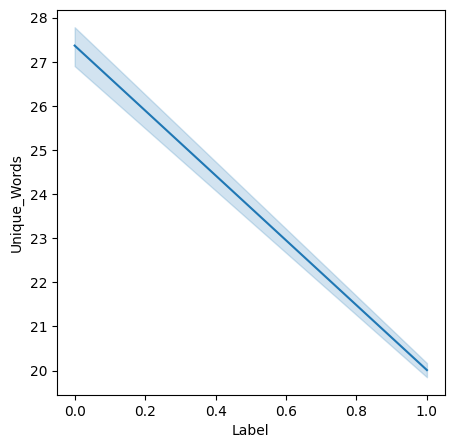

In [50]:
plt.figure(figsize=(5,5))
sns.lineplot(y='Unique_Words',x='Label',data=df)

In [65]:
y=df[['Label']]
x=df[['Number_of_Sentence']]
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [66]:
log=LogisticRegression()
log.fit(X_train,y_train)
y_pred=log.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy score :{accuracy:.4f}")


Accuracy score :0.6652


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [67]:
rmse_log=np.sqrt(mean_squared_error(y_test,y_pred))
print(f"Root mean squared error for Logistic Regression :{rmse_log}")

Root mean squared error for Logistic Regression :0.5786318473907349


In [68]:
random=RandomForestClassifier()
random.fit(X_train,y_train)
y_pred=random.predict(X_test)
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy score :{accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Accuracy score :0.6652


In [73]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f"Root mean squared error for Random Forest:{rmse:.4f}")

Root mean squared error for Random Forest:0.5786


In [70]:
support=SVC()
support.fit(X_train,y_train)
y_pred=support.predict(X_test)
accuracy_1=accuracy_score(y_test,y_pred)
print(f"Accuracy score :{accuracy_1:.4f}")

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Accuracy score :0.6652


In [74]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(f"Root mean squared error SVM :{rmse:.4f}")

Root mean squared error SVM :0.5786
